# Examine the data frame calculate_amplitudes_skipped_picks_2.csv

This notebook is used to check the data frame called calculate_amplitudes_skipped_picks_2.csv

Agentic AI was used in this notebook. 

By Hiroto Bito

In [2]:
import os
import sys
import numpy as np
import pandas as pd
from tqdm import tqdm
from obspy import UTCDateTime
import matplotlib.pyplot as plt
import time
from obspy.core.stream import Stream


parent_dir = '/home/hbito/cascadia_obs_ensemble/utils'
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from data_client import get_waveforms

In [3]:
# Prepare the file paths
datasets_dir =  '/wd1/hbito_data/data/datasets_all_regions'
path = f'{datasets_dir}/calculate_amplitudes_skipped_picks_2.csv'

In [4]:
skipped_picks_df = pd.read_csv(path, index_col=False).copy()
skipped_picks_df.head(10)

,network,station,channel,origin_time,time_pick,starttime,endtime,reason
0,UW,SP2,*H*,2010-04-30T16:01:16.639000Z,2010-04-30T16:01:35.360000Z,2010-04-30T16:01:05.360000Z,2010-04-30T16:04:05.360000Z,Request failed: No Vertical Component Data Pre...
1,UW,SP2,*H*,2010-05-01T04:18:47.446000Z,2010-05-01T04:18:57.850000Z,2010-05-01T04:18:27.850000Z,2010-05-01T04:21:27.850000Z,Request failed: No Vertical Component Data Pre...
2,UW,SP2,*H*,2010-06-22T15:49:24.169000Z,2010-06-22T15:49:37.870000Z,2010-06-22T15:49:07.870000Z,2010-06-22T15:52:07.870000Z,Request failed: No Vertical Component Data Pre...
3,UW,SP2,*H*,2010-07-31T04:04:17.592000Z,2010-07-31T04:05:02.760000Z,2010-07-31T04:04:32.760000Z,2010-07-31T04:07:32.760000Z,Request failed: No Vertical Component Data Pre...
4,UW,SP2,*H*,2010-08-09T03:50:22.194000Z,2010-08-09T03:50:52.920000Z,2010-08-09T03:50:22.920000Z,2010-08-09T03:53:22.920000Z,Request failed: No Vertical Component Data Pre...
5,UW,SP2,*H*,2010-08-11T13:06:01.021000Z,2010-08-11T13:06:19.890000Z,2010-08-11T13:05:49.890000Z,2010-08-11T13:08:49.890000Z,Request failed: No Vertical Component Data Pre...
6,CN,BTB,*H*,2012-02-26T13:29:28.280000Z,2012-02-26T13:30:11.960000Z,2012-02-26T13:29:41.960000Z,2012-02-26T13:32:41.960000Z,Request failed: No Vertical Component Data Pre...
7,CN,BTB,*H*,2012-03-02T16:39:18.794000Z,2012-03-02T16:39:41.720000Z,2012-03-02T16:39:11.720000Z,2012-03-02T16:42:11.720000Z,Request failed: No Vertical Component Data Pre...
8,NC,KRMB,*H*,2012-03-03T16:04:55.967000Z,2012-03-03T16:05:19.520000Z,2012-03-03T16:04:49.520000Z,2012-03-03T16:07:49.520000Z,Request failed: No Vertical Component Data Pre...
9,CN,VGZ,*H*,2012-04-24T23:59:59.389000Z,2012-04-25T00:00:05.000000Z,2012-04-24T23:59:35.000000Z,2012-04-25T00:02:35.000000Z,Request failed: No Vertical Component Data Pre...


In [5]:
skipped_picks_df['network_station'] = skipped_picks_df['network'] + '.' + skipped_picks_df['station'] + '.'
skipped_picks_df.head()

,network,station,channel,origin_time,time_pick,starttime,endtime,reason,network_station
0,UW,SP2,*H*,2010-04-30T16:01:16.639000Z,2010-04-30T16:01:35.360000Z,2010-04-30T16:01:05.360000Z,2010-04-30T16:04:05.360000Z,Request failed: No Vertical Component Data Pre...,UW.SP2.
1,UW,SP2,*H*,2010-05-01T04:18:47.446000Z,2010-05-01T04:18:57.850000Z,2010-05-01T04:18:27.850000Z,2010-05-01T04:21:27.850000Z,Request failed: No Vertical Component Data Pre...,UW.SP2.
2,UW,SP2,*H*,2010-06-22T15:49:24.169000Z,2010-06-22T15:49:37.870000Z,2010-06-22T15:49:07.870000Z,2010-06-22T15:52:07.870000Z,Request failed: No Vertical Component Data Pre...,UW.SP2.
3,UW,SP2,*H*,2010-07-31T04:04:17.592000Z,2010-07-31T04:05:02.760000Z,2010-07-31T04:04:32.760000Z,2010-07-31T04:07:32.760000Z,Request failed: No Vertical Component Data Pre...,UW.SP2.
4,UW,SP2,*H*,2010-08-09T03:50:22.194000Z,2010-08-09T03:50:52.920000Z,2010-08-09T03:50:22.920000Z,2010-08-09T03:53:22.920000Z,Request failed: No Vertical Component Data Pre...,UW.SP2.


In [6]:
len(skipped_picks_df.drop_duplicates(subset='network_station'))

20

Plot the histogram of the stations 

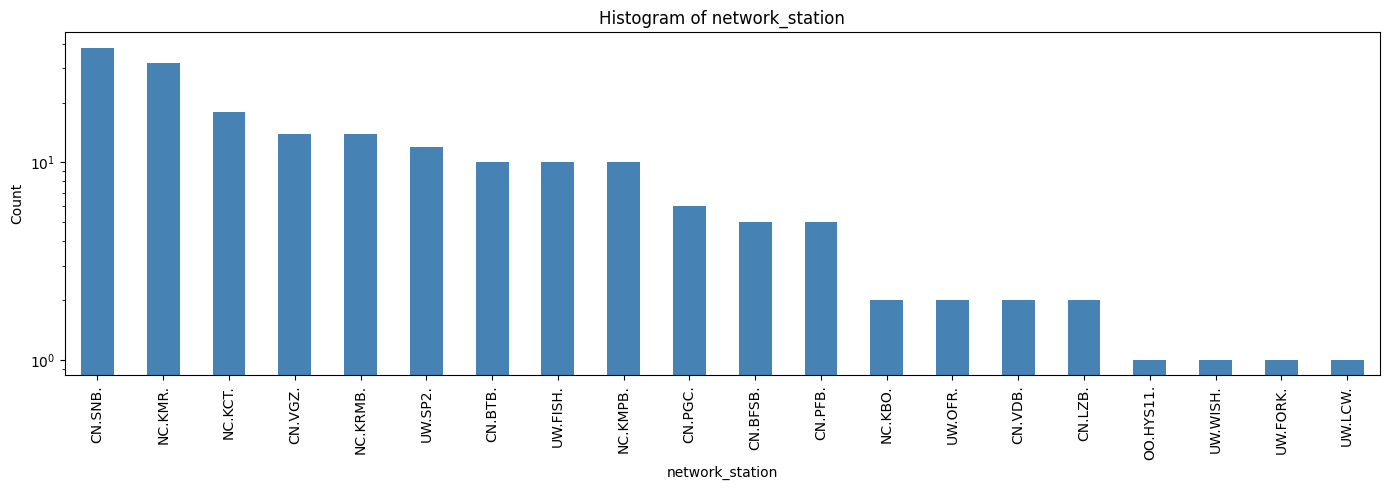

In [7]:
network_station_counts = skipped_picks_df['network_station'].value_counts()
ax = network_station_counts.plot(kind='bar', figsize=(14, 5), color='steelblue')
ax.set_title('Histogram of network_station')
ax.set_xlabel('network_station')
ax.set_ylabel('Count')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

Plot the histogram of the networks 

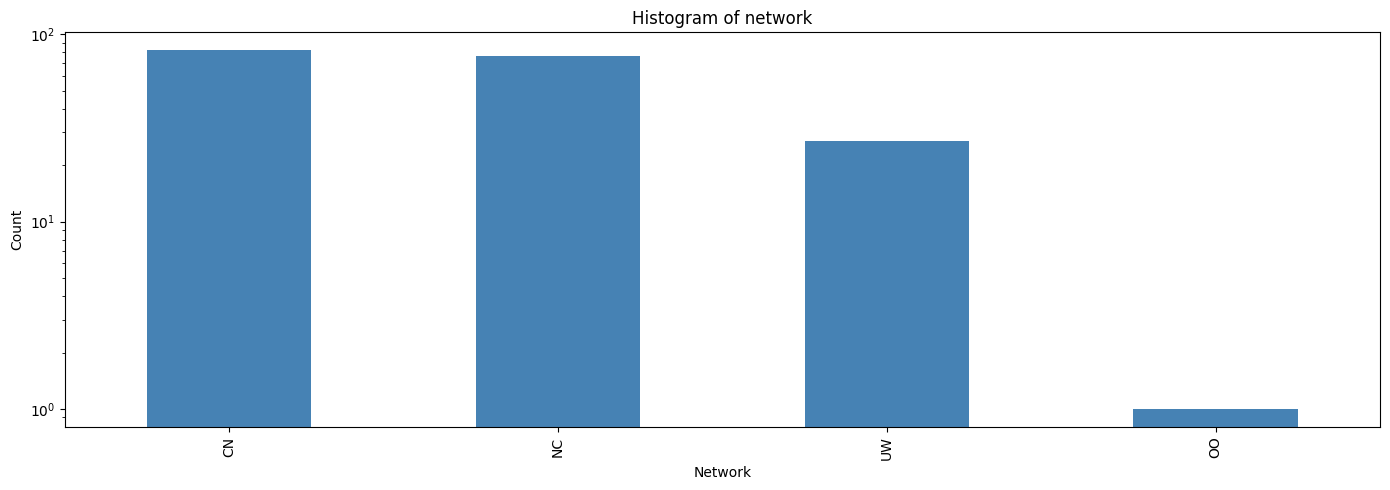

In [8]:
network_counts = skipped_picks_df['network'].value_counts()
ax = network_counts.plot(kind='bar', figsize=(14, 5), color='steelblue')
ax.set_title('Histogram of network')
ax.set_xlabel('Network')
ax.set_ylabel('Count')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

In [9]:
# Count the number of stations in each network
network_counts

CN    82
NC    76
UW    27
OO     1
Name: network, dtype: int64

In [10]:
network_counts.sum()

186

In [11]:
network_counts.keys()

Index(['CN', 'NC', 'UW', 'OO'], dtype='object')

Count the reasons the specific stations and times were skipped during the amplitude calculation

In [12]:
reason_counts = skipped_picks_df['reason'].value_counts()
reason_counts

Request failed: No data available for request.\nHTTP Status code: 204\nDetailed response of server:\n\n                                 8
Request failed: No data available at NC.KRMB with HHZ, BHZ or EHZ channels at 2012-11-19T10:20:13.150000Z. Skipping.                    2
Request failed: No Vertical Component Data Present at NC.KRMB with HHZ, BHZ or EHZ channels at 2012-11-19T14:16:06.510000Z. Skipping    2
Request failed: No Vertical Component Data Present at NC.KRMB with HHZ, BHZ or EHZ channels at 2012-03-03T16:05:19.520000Z. Skipping    2
Request failed: No Vertical Component Data Present at CN.VGZ with HHZ, BHZ or EHZ channels at 2012-04-25T00:00:05.000000Z. Skipping     2
                                                                                                                                       ..
Request failed: No Vertical Component Data Present at NC.KRMB with HHZ, BHZ or EHZ channels at 2013-03-21T03:50:18.900000Z. Skipping    1
Request failed: No Vertical Compon

Check the reason the amplitudes of the following UW stations were not calculated in the second run of the amplitude calculation

In [13]:
subset_network = skipped_picks_df[skipped_picks_df['network']=='UW']
subset_network.head()

,network,station,channel,origin_time,time_pick,starttime,endtime,reason,network_station
0,UW,SP2,*H*,2010-04-30T16:01:16.639000Z,2010-04-30T16:01:35.360000Z,2010-04-30T16:01:05.360000Z,2010-04-30T16:04:05.360000Z,Request failed: No Vertical Component Data Pre...,UW.SP2.
1,UW,SP2,*H*,2010-05-01T04:18:47.446000Z,2010-05-01T04:18:57.850000Z,2010-05-01T04:18:27.850000Z,2010-05-01T04:21:27.850000Z,Request failed: No Vertical Component Data Pre...,UW.SP2.
2,UW,SP2,*H*,2010-06-22T15:49:24.169000Z,2010-06-22T15:49:37.870000Z,2010-06-22T15:49:07.870000Z,2010-06-22T15:52:07.870000Z,Request failed: No Vertical Component Data Pre...,UW.SP2.
3,UW,SP2,*H*,2010-07-31T04:04:17.592000Z,2010-07-31T04:05:02.760000Z,2010-07-31T04:04:32.760000Z,2010-07-31T04:07:32.760000Z,Request failed: No Vertical Component Data Pre...,UW.SP2.
4,UW,SP2,*H*,2010-08-09T03:50:22.194000Z,2010-08-09T03:50:52.920000Z,2010-08-09T03:50:22.920000Z,2010-08-09T03:53:22.920000Z,Request failed: No Vertical Component Data Pre...,UW.SP2.


In [14]:
# Define the arguments
window_before = 30 # in sec
window_after = 150 # in sec
source='pnwstore'

In [15]:
count = 0
df = subset_network

for idx, row in df.iterrows():
    count += 1
    origin_time_str = row['origin_time']
    origin_time = UTCDateTime(origin_time_str)

    time_pick_str = row['time_pick']
    time_pick = UTCDateTime(time_pick_str)

    network = row['network']
    station = row['station']
    channel = '*H*'

    starttime = time_pick - window_before 
    endtime = time_pick + window_after

    print(f'Pick: {count}/{len(df)} Network: {network} Station: {station} Origin Time: {origin_time_str} Pick Time: {time_pick_str}')

    time.sleep(0.1)
   
    try:
        st = get_waveforms(network=network, station=station, channel=channel,
                            starttime=starttime, endtime=endtime,
                            source=source)
    except Exception as e:
        print(f"Request failed: {e}")

        continue

    print('-------')
    print(st)
    print('-------')
    
    # time.sleep(0.1)


    # Create a new stream
    sdata = Stream()
    
    # Check if loaded data have a vertical component (minimum requirement)
    has_Z = bool(st.select(channel='??Z'))
    # Check for the presence of HH, BH, and EH channels
    has_HH = bool(st.select(channel='HH?'))
    has_BH = bool(st.select(channel='BH?'))
    has_EH = bool(st.select(channel='EH?'))

    if not has_Z:
        e = f'No Vertical Component Data Present at {network}.{station} with HHZ, BHZ or EHZ channels at {time_pick_str}. Skipping'
        print(e)
        print('===============================================================')
        continue

    print('===============================================================')

 

Pick: 1/27 Network: UW Station: SP2 Origin Time: 2010-04-30T16:01:16.639000Z Pick Time: 2010-04-30T16:01:35.360000Z


PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


-------
1 Trace(s) in Stream:
UW.SP2..HHN | 2010-04-30T16:01:35.440000Z - 2010-04-30T16:02:55.420000Z | 100.0 Hz, 7999 samples
-------
No Vertical Component Data Present at UW.SP2 with HHZ, BHZ or EHZ channels at 2010-04-30T16:01:35.360000Z. Skipping
Pick: 2/27 Network: UW Station: SP2 Origin Time: 2010-05-01T04:18:47.446000Z Pick Time: 2010-05-01T04:18:57.850000Z


PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


-------
1 Trace(s) in Stream:
UW.SP2..HHN | 2010-05-01T04:18:57.930000Z - 2010-05-01T04:19:00.420000Z | 100.0 Hz, 250 samples
-------
No Vertical Component Data Present at UW.SP2 with HHZ, BHZ or EHZ channels at 2010-05-01T04:18:57.850000Z. Skipping
Pick: 3/27 Network: UW Station: SP2 Origin Time: 2010-06-22T15:49:24.169000Z Pick Time: 2010-06-22T15:49:37.870000Z


...

-------
1 Trace(s) in Stream:
UW.FISH..BHE | 2013-06-29T01:21:21.625000Z - 2013-06-29T01:24:21.625000Z | 40.0 Hz, 7201 samples
-------
No Vertical Component Data Present at UW.FISH with HHZ, BHZ or EHZ channels at 2013-06-29T01:21:51.625000Z. Skipping
Pick: 24/27 Network: UW Station: FISH Origin Time: 2013-06-29T01:21:19.040000Z Pick Time: 2013-06-29T01:22:15.675000Z
-------
1 Trace(s) in Stream:
UW.FISH..BHE | 2013-06-29T01:21:45.675000Z - 2013-06-29T01:24:45.675000Z | 40.0 Hz, 7201 samples
-------
No Vertical Component Data Present at UW.FISH with HHZ, BHZ or EHZ channels at 2013-06-29T01:22:15.675000Z. Skipping
Pick: 25/27 Network: UW Station: FORK Origin Time: 2013-08-03T23:15:55.332000Z Pick Time: 2013-08-03T23:16:19.794188Z


PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09
PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


-------
5 Trace(s) in Stream:
UW.FORK..BHE | 2013-08-03T23:16:19.865000Z - 2013-08-03T23:16:28.523537Z | 41.0 Hz, 356 samples
UW.FORK..BHE | 2013-08-03T23:17:36.455200Z - 2013-08-03T23:17:40.650322Z | 41.0 Hz, 173 samples
UW.FORK..BHN | 2013-08-03T23:16:39.817400Z - 2013-08-03T23:16:48.768620Z | 41.0 Hz, 368 samples
UW.FORK..BHN | 2013-08-03T23:17:41.574700Z - 2013-08-03T23:17:45.696651Z | 41.0 Hz, 170 samples
UW.FORK..BHN | 2013-08-03T23:17:58.415000Z - 2013-08-03T23:18:06.268659Z | 41.0 Hz, 323 samples
-------
No Vertical Component Data Present at UW.FORK with HHZ, BHZ or EHZ channels at 2013-08-03T23:16:19.794188Z. Skipping
Pick: 26/27 Network: UW Station: WISH Origin Time: 2014-06-04T05:24:54.177000Z Pick Time: 2014-06-04T05:25:12.490000Z
-------
0 Trace(s) in Stream:

-------
No Vertical Component Data Present at UW.WISH with HHZ, BHZ or EHZ channels at 2014-06-04T05:25:12.490000Z. Skipping
Pick: 27/27 Network: UW Station: LCW Origin Time: 2014-12-02T00:00:03.390000Z Pick Time: 20

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


-------
0 Trace(s) in Stream:

-------
No Vertical Component Data Present at UW.LCW with HHZ, BHZ or EHZ channels at 2014-12-02T00:00:29.730012Z. Skipping


Check the reason the amplitudes of the following CN stations were not calculated in the second run of the amplitude calculation

In [15]:
subset_network1 = skipped_picks_df[skipped_picks_df['network']=='CN']
subset_network1

,network,station,channel,origin_time,time_pick,starttime,endtime,reason,network_station
6,CN,BTB,*H*,2012-02-26T13:29:28.280000Z,2012-02-26T13:30:11.960000Z,2012-02-26T13:29:41.960000Z,2012-02-26T13:32:41.960000Z,Request failed: No Vertical Component Data Pre...,CN.BTB.
7,CN,BTB,*H*,2012-03-02T16:39:18.794000Z,2012-03-02T16:39:41.720000Z,2012-03-02T16:39:11.720000Z,2012-03-02T16:42:11.720000Z,Request failed: No Vertical Component Data Pre...,CN.BTB.
9,CN,VGZ,*H*,2012-04-24T23:59:59.389000Z,2012-04-25T00:00:05.000000Z,2012-04-24T23:59:35.000000Z,2012-04-25T00:02:35.000000Z,Request failed: No Vertical Component Data Pre...,CN.VGZ.
10,CN,SNB,*H*,2012-04-24T23:59:59.389000Z,2012-04-25T00:00:09.640000Z,2012-04-24T23:59:39.640000Z,2012-04-25T00:02:39.640000Z,Request failed: No Vertical Component Data Pre...,CN.SNB.
11,CN,PFB,*H*,2012-04-24T23:59:59.389000Z,2012-04-25T00:00:12.250000Z,2012-04-24T23:59:42.250000Z,2012-04-25T00:02:42.250000Z,Request failed: No Vertical Component Data Pre...,CN.PFB.
...,...,...,...,...,...,...,...,...,...
116,CN,BFSB,*H*,2013-11-18T23:59:56.089000Z,2013-11-19T00:00:26.770000Z,2013-11-18T23:59:56.770000Z,2013-11-19T00:02:56.770000Z,Request failed: No Vertical Component Data Pre...,CN.BFSB.
117,CN,BFSB,*H*,2013-11-23T22:32:45.877000Z,2013-11-23T22:33:27.540000Z,2013-11-23T22:32:57.540000Z,2013-11-23T22:35:57.540000Z,Request failed: No Vertical Component Data Pre...,CN.BFSB.
118,CN,BFSB,*H*,2013-11-25T04:48:20.080000Z,2013-11-25T04:49:41.420000Z,2013-11-25T04:49:11.420000Z,2013-11-25T04:52:11.420000Z,Request failed: No Vertical Component Data Pre...,CN.BFSB.
119,CN,BFSB,*H*,2013-11-25T07:30:29.447000Z,2013-11-25T07:31:04.370000Z,2013-11-25T07:30:34.370000Z,2013-11-25T07:33:34.370000Z,Request failed: No Vertical Component Data Pre...,CN.BFSB.


In [16]:
# Define the arguments
window_before = 30 # in sec
window_after = 150 # in sec
source='pnwstore'

In [17]:
count = 0

for idx, row in subset_network1.iterrows():
    count += 1
    origin_time_str = row['origin_time']
    origin_time = UTCDateTime(origin_time_str)

    time_pick_str = row['time_pick']
    time_pick = UTCDateTime(time_pick_str)

    network = row['network']
    station = row['station']
    channel = '*H*'

    starttime = time_pick - window_before 
    endtime = time_pick + window_after

    print(f'Pick: {count}/{len(subset_network1)} Network: {network} Station: {station} Origin Time: {origin_time_str} Pick Time: {time_pick_str}')

    time.sleep(0.1)
   
    try:
        st = get_waveforms(network=network, station=station, channel=channel,
                            starttime=starttime, endtime=endtime,
                            source=source)
    except Exception as e:
        print(f"Request failed: {e}")

        continue

    print('-------')
    print(st)
    print('-------')
    
    # time.sleep(0.1)


    # Create a new stream
    sdata = Stream()
    
    # Check if loaded data have a vertical component (minimum requirement)
    has_Z = bool(st.select(channel='??Z'))
    # Check for the presence of HH, BH, and EH channels
    has_HH = bool(st.select(channel='HH?'))
    has_BH = bool(st.select(channel='BH?'))
    has_EH = bool(st.select(channel='EH?'))

    if not has_Z:
        e = f'No Vertical Component Data Present at {network}.{station} with HHZ, BHZ or EHZ channels at {time_pick_str}. Skipping'
        print(e)
        print('===============================================================')
        continue

    print('===============================================================')

 

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


Pick: 1/82 Network: CN Station: BTB Origin Time: 2012-02-26T13:29:28.280000Z Pick Time: 2012-02-26T13:30:11.960000Z


PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


-------
2 Trace(s) in Stream:
CN.BTB..HHE | 2012-02-26T13:30:36.000000Z - 2012-02-26T13:30:41.990000Z | 100.0 Hz, 600 samples
CN.BTB..HHE | 2012-02-26T13:32:18.000000Z - 2012-02-26T13:32:23.990000Z | 100.0 Hz, 600 samples
-------
No Vertical Component Data Present at CN.BTB with HHZ, BHZ or EHZ channels at 2012-02-26T13:30:11.960000Z. Skipping
Pick: 2/82 Network: CN Station: BTB Origin Time: 2012-03-02T16:39:18.794000Z Pick Time: 2012-03-02T16:39:41.720000Z


PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


...

-------
2 Trace(s) in Stream:
CN.BFSB..HHE | 2013-11-23T22:32:57.540000Z - 2013-11-23T22:35:57.540000Z | 100.0 Hz, 18001 samples
CN.BFSB..HHN | 2013-11-23T22:32:57.540000Z - 2013-11-23T22:35:57.540000Z | 100.0 Hz, 18001 samples
-------
No Vertical Component Data Present at CN.BFSB with HHZ, BHZ or EHZ channels at 2013-11-23T22:33:27.540000Z. Skipping
Pick: 80/82 Network: CN Station: BFSB Origin Time: 2013-11-25T04:48:20.080000Z Pick Time: 2013-11-25T04:49:41.420000Z


PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


-------
1 Trace(s) in Stream:
CN.BFSB..HHE | 2013-11-25T04:49:11.420000Z - 2013-11-25T04:52:11.420000Z | 100.0 Hz, 18001 samples
-------
No Vertical Component Data Present at CN.BFSB with HHZ, BHZ or EHZ channels at 2013-11-25T04:49:41.420000Z. Skipping
Pick: 81/82 Network: CN Station: BFSB Origin Time: 2013-11-25T07:30:29.447000Z Pick Time: 2013-11-25T07:31:04.370000Z


PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


-------
1 Trace(s) in Stream:
CN.BFSB..HHE | 2013-11-25T07:30:34.370000Z - 2013-11-25T07:33:34.370000Z | 100.0 Hz, 18001 samples
-------
No Vertical Component Data Present at CN.BFSB with HHZ, BHZ or EHZ channels at 2013-11-25T07:31:04.370000Z. Skipping
Pick: 82/82 Network: CN Station: PFB Origin Time: 2014-01-14T23:59:57.483000Z Pick Time: 2014-01-15T00:00:18.050000Z
-------
0 Trace(s) in Stream:

-------
No Vertical Component Data Present at CN.PFB with HHZ, BHZ or EHZ channels at 2014-01-15T00:00:18.050000Z. Skipping


In [18]:
# # Check the number of picks that were skipped because no vertical components were present
# subset_v_comp = subset_network1[subset_network1['reason'].str.contains('Request failed: No Vertical Component Data Present',na=False)]
# print('len(subset_v_comp): ', len(subset_v_comp))
# subset_v_comp.head()

Check the reason the amplitudes of the following NC stations were not calculated in the second run of the amplitude calculation

In [16]:
subset_network2 = skipped_picks_df[skipped_picks_df['network']=='NC']
subset_network2.head()

,network,station,channel,origin_time,time_pick,starttime,endtime,reason,network_station
8,NC,KRMB,*H*,2012-03-03T16:04:55.967000Z,2012-03-03T16:05:19.520000Z,2012-03-03T16:04:49.520000Z,2012-03-03T16:07:49.520000Z,Request failed: No Vertical Component Data Pre...,NC.KRMB.
28,NC,KRMB,*H*,2012-05-02T13:22:48.458000Z,2012-05-02T13:23:27.830000Z,2012-05-02T13:22:57.830000Z,2012-05-02T13:25:57.830000Z,Request failed: No Vertical Component Data Pre...,NC.KRMB.
47,NC,KRMB,*H*,2012-11-19T10:19:59.265000Z,2012-11-19T10:20:08.190000Z,2012-11-19T10:19:38.190000Z,2012-11-19T10:22:38.190000Z,Request failed: No data available at NC.KRMB w...,NC.KRMB.
48,NC,KRMB,*H*,2012-11-19T10:19:59.265000Z,2012-11-19T10:20:13.150000Z,2012-11-19T10:19:43.150000Z,2012-11-19T10:22:43.150000Z,Request failed: No data available at NC.KRMB w...,NC.KRMB.
49,NC,KRMB,*H*,2012-11-19T14:15:08.425000Z,2012-11-19T14:16:06.510000Z,2012-11-19T14:15:36.510000Z,2012-11-19T14:18:36.510000Z,Request failed: No Vertical Component Data Pre...,NC.KRMB.


In [17]:
# Define the arguments
window_before = 30 # in sec
window_after = 150 # in sec
source='pnwstore'

In [19]:
count = 0
df = subset_network2

for idx, row in df.iterrows():
    count += 1
    origin_time_str = row['origin_time']
    origin_time = UTCDateTime(origin_time_str)

    time_pick_str = row['time_pick']
    time_pick = UTCDateTime(time_pick_str)

    network = row['network']
    station = row['station']
    channel = 'HH*'

    starttime = time_pick - window_before 
    endtime = time_pick + window_after

    print(f'Pick: {count}/{len(df)} Network: {network} Station: {station} Origin Time: {origin_time_str} Pick Time: {time_pick_str}')

    time.sleep(0.1)
   
    try:
        st = get_waveforms(network=network, station=station, channel=channel,
                            starttime=starttime, endtime=endtime,
                            source=source)
    except Exception as e:
        print(f"Request failed: {e}")
        print('===============================================================')
        continue

    print('-------')
    print(st)
    print('-------')
    
    # time.sleep(0.1)


    # Create a new stream
    sdata = Stream()
    
    # Check if loaded data have a vertical component (minimum requirement)
    has_Z = bool(st.select(channel='??Z'))
    # Check for the presence of HH, BH, and EH channels
    has_HH = bool(st.select(channel='HH?'))
    has_BH = bool(st.select(channel='BH?'))
    has_EH = bool(st.select(channel='EH?'))

    if not has_Z:
        e = f'No Vertical Component Data Present at {network}.{station} with HHZ, BHZ or EHZ channels at {time_pick_str}. Skipping'
        print(e)
        print('===============================================================')
        continue

    print('===============================================================')

 

Pick: 1/76 Network: NC Station: KRMB Origin Time: 2012-03-03T16:04:55.967000Z Pick Time: 2012-03-03T16:05:19.520000Z
-------
1 Trace(s) in Stream:
NC.KRMB..HHN | 2012-03-03T16:05:19.660000Z - 2012-03-03T16:07:39.730000Z | 100.0 Hz, 14008 samples
-------
No Vertical Component Data Present at NC.KRMB with HHZ, BHZ or EHZ channels at 2012-03-03T16:05:19.520000Z. Skipping
Pick: 2/76 Network: NC Station: KRMB Origin Time: 2012-05-02T13:22:48.458000Z Pick Time: 2012-05-02T13:23:27.830000Z
-------
1 Trace(s) in Stream:
NC.KRMB..HHE | 2012-05-02T13:22:57.830000Z - 2012-05-02T13:23:51.730000Z | 100.0 Hz, 5391 samples
-------
No Vertical Component Data Present at NC.KRMB with HHZ, BHZ or EHZ channels at 2012-05-02T13:23:27.830000Z. Skipping
Pick: 3/76 Network: NC Station: KRMB Origin Time: 2012-11-19T10:19:59.265000Z Pick Time: 2012-11-19T10:20:08.190000Z
Request failed: No data available for request.
HTTP Status code: 204
Detailed response of server:


Pick: 4/76 Network: NC Station: KRMB Origi

Check the reason the amplitude of the following OO station was not calculated in the second run of the amplitude calculation

In [22]:
subset_network3 = skipped_picks_df[skipped_picks_df['network']=='OO']
subset_network3.head()

,network,station,channel,origin_time,time_pick,starttime,endtime,reason,network_station
124,OO,HYS11,*H*,2014-11-14T18:34:03.856000Z,2014-11-14T18:35:01.050000Z,2014-11-14T18:34:31.050000Z,2014-11-14T18:37:31.050000Z,Request failed: No Vertical Component Data Pre...,OO.HYS11.


In [23]:
# Define the arguments
window_before = 30 # in sec
window_after = 150 # in sec
source='pnwstore'

In [24]:
count = 0
df = subset_network3

for idx, row in df.iterrows():
    count += 1
    origin_time_str = row['origin_time']
    origin_time = UTCDateTime(origin_time_str)

    time_pick_str = row['time_pick']
    time_pick = UTCDateTime(time_pick_str)

    network = row['network']
    station = row['station']
    channel = '*H*'

    starttime = time_pick - window_before 
    endtime = time_pick + window_after

    print(f'Pick: {count}/{len(df)} Network: {network} Station: {station} Origin Time: {origin_time_str} Pick Time: {time_pick_str}')

    time.sleep(0.1)
   
    try:
        st = get_waveforms(network=network, station=station, channel=channel,
                            starttime=starttime, endtime=endtime,
                            source=source)
    except Exception as e:
        print(f"Request failed: {e}")
        print('===============================================================')
        continue

    print('-------')
    print(st)
    print('-------')
    
    # time.sleep(0.1)


    # Create a new stream
    sdata = Stream()
    
    # Check if loaded data have a vertical component (minimum requirement)
    has_Z = bool(st.select(channel='??Z'))
    # Check for the presence of HH, BH, and EH channels
    has_HH = bool(st.select(channel='HH?'))
    has_BH = bool(st.select(channel='BH?'))
    has_EH = bool(st.select(channel='EH?'))

    if not has_Z:
        e = f'No Vertical Component Data Present at {network}.{station} with HHZ, BHZ or EHZ channels at {time_pick_str}. Skipping'
        print(e)
        print('===============================================================')
        continue

    print('===============================================================')

 

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


Pick: 1/1 Network: OO Station: HYS11 Origin Time: 2014-11-14T18:34:03.856000Z Pick Time: 2014-11-14T18:35:01.050000Z
-------
1 Trace(s) in Stream:
OO.HYS11..EHN | 2014-11-14T18:34:31.050000Z - 2014-11-14T18:37:22.260000Z | 200.0 Hz, 34243 samples
-------
No Vertical Component Data Present at OO.HYS11 with HHZ, BHZ or EHZ channels at 2014-11-14T18:35:01.050000Z. Skipping
